# Section 4: Language Models Exploration (BERT)
This notebook implements a **Transfer Learning** approach using **BERT (bert-base-uncased)** to classify SSH commands into cybersecurity intent categories (Multi-Label Classification).

**Key Steps:**
1.  **Preprocessing:** Data cleaning and Stratified Splitting.
2.  **Smart Tokenization:** Caching tokenized data to disk to speed up re-runs.
3.  **Model Training:** Fine-tuning a Custom BERT architecture with Early Stopping logic.
4.  **Evaluation:** Comprehensive metrics (F1-Score, ROC-AUC) and visualization (Confusion Matrices, Loss Curves).

### Imports and Device Setup
Importing necessary libraries (PyTorch, Transformers, Sklearn) and configuring the GPU/CPU device.

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, Dataset
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jl

# Check device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)       #to be sure to use the GPU for faster computation

c:\Users\mitil\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


### Data Loading & Label Encoding
Loads the dataset and prepares the target variable (`Set_Fingerprint`). We use `MultiLabelBinarizer` to convert the list of intents into a binary matrix (One-Hot Encoding) required for multi-label classification.

In [10]:
df = jl.load("df.pkl")
#df = df.sample(80000, random_state=42)
df['Set_Fingerprint'] = df['Set_Fingerprint'].apply(lambda x: [str(i).strip() for i in x])
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['Set_Fingerprint'])
print(mlb.classes_)

['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']


### Stratified Data Splitting
Splits the dataset into **Training (60%)**, **Validation (20%)**, and **Test (20%)** sets. A two-step `train_test_split` is used to ensure clean separation of data for model tuning and final evaluation.

In [11]:
# Split data into Train (60%), Validation (20%), and Test (20%)
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['full_session'], y, test_size=0.2, random_state=42
)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.25, random_state=42
)

### Smart Tokenization (Cached)
Initializes the **BERT Tokenizer** and converts raw text into numerical tensors (`input_ids`, `attention_mask`). Implements a **caching mechanism**: it checks for previously saved `.pt` files to skip this heavy computation on future runs. A `FORCE_RETOKENIZE` flag is included to manually trigger re-processing when the dataset changes.

In [12]:
import os

data_dir = "../Processed/"
os.makedirs(data_dir, exist_ok=True)

# SWITCH THIS TO TRUE IF YOU CHANGE YOUR DATASET. TO FORCE RETOKENIZATION e.g Changed sample size
FORCE_RETOKENIZE = False    #set back to false after removing the downsample (just used to test)

train_file = os.path.join(data_dir, "train_encodings.pt")
val_file = os.path.join(data_dir, "val_encodings.pt")
test_file = os.path.join(data_dir, "test_encodings.pt")

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

if os.path.exists(train_file) and os.path.exists(val_file) and os.path.exists(test_file) and not FORCE_RETOKENIZE:
    print("Found saved tokenized data! Loading from disk...")
    # Load the dictionaries containing encodings AND labels
    train_data = torch.load(train_file,weights_only=False)
    val_data = torch.load(val_file,weights_only=False)
    test_data = torch.load(test_file,weights_only=False)
    
    # Unpack them back into variables
    train_encodings = train_data['encodings']
    train_labels = train_data['labels']
    
    val_encodings = val_data['encodings']
    val_labels = val_data['labels']
    
    test_encodings = test_data['encodings']
    test_labels = test_data['labels']
    
    print("Data loaded successfully. Tokenization skipped.")

else:
    if FORCE_RETOKENIZE:
        print("FORCE_RETOKENIZE is True. Overwriting old files...")
    else:
        print("Saved data not found. Starting tokenization...")


    train_texts_cleaned = list(train_texts.fillna("").astype(str))
    val_texts_cleaned = list(val_texts.fillna("").astype(str))
    test_texts_cleaned = list(test_texts.fillna("").astype(str))

    # 2. Tokenize the Training Set
    train_encodings = tokenizer(
        train_texts_cleaned,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    # 3. Tokenize the Validation Set
    val_encodings = tokenizer(
        val_texts_cleaned,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    # 4. Tokenize the Test Set
    test_encodings = tokenizer(
        test_texts_cleaned,
        truncation=True,
        padding=True,
        max_length=128,
        return_tensors="pt"
    )

    #Since this operation might take time save the tokenized data
    print("Saving tokenized data to disk...")
    torch.save({'encodings': train_encodings, 'labels': train_labels}, train_file)
    torch.save({'encodings': val_encodings, 'labels': val_labels}, val_file)
    torch.save({'encodings': test_encodings, 'labels': test_labels}, test_file)
    
    print("Tokenization complete and saved.")


Found saved tokenized data! Loading from disk...
Data loaded successfully. Tokenization skipped.


### Custom Dataset Definition
Defining the `SSHDataset` class, which inherits from PyTorch's `Dataset`. It structures the tokenized inputs (`input_ids`, `attention_mask`) and corresponding labels into a format compatible with the DataLoaders.

In [13]:
class SSHDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx].clone().detach(),
            'attention_mask': self.encodings['attention_mask'][idx].clone().detach(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float)
        }

    def __len__(self):
        return len(self.labels)

### DataLoader Instantiation
Creates `SSHDataset` instances for the training, validation, and test sets and wraps them in PyTorch `DataLoader` objects. These loaders handle batching (size 16) and shuffling (for training), enabling efficient iteration during the model training process.

In [14]:
import os

train_dataset = SSHDataset(train_encodings, train_labels)
val_dataset = SSHDataset(val_encodings, val_labels)
test_dataset = SSHDataset(test_encodings, test_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("batches")
print(f"Train DataLoader: {len(train_loader)}")
print(f"Validation DataLoader: {len(val_loader)}")
print(f"Test DataLoader: {len(test_loader)}")


batches
Train DataLoader: 8739
Validation DataLoader: 2913
Test DataLoader: 2913


### Model Architecture Definition
Defines the `CustomBERTModel` class. This architecture uses a pre-trained **BERT** backbone (`bert-base-uncased`) to extract contextual features. The model takes the `[CLS]` token embedding from the last hidden layer and passes it through a linear classifier to generate logits for each intent class. Finally, the model is initialized and moved to the GPU.

In [15]:
bert_model = BertModel.from_pretrained('bert-base-uncased')

class CustomBERTModel(torch.nn.Module):
    def __init__(self, bert_model, num_labels):
        super(CustomBERTModel, self).__init__()
        self.bert = bert_model
        self.classifier = torch.nn.Linear(bert_model.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

model = CustomBERTModel(bert_model, num_labels=y.shape[1])
model.to(device)    


CustomBERTModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

### Optimizer & Training Configuration
Configures the training setup. We **freeze the BERT backbone** to perform Transfer Learning, training only the classification head. The **AdamW** optimizer is set up with a linear learning rate scheduler, and **Mixed Precision (GradScaler)** is enabled for faster training. **BCEWithLogitsLoss** is used as the loss function, which is standard for multi-label tasks.

In [16]:
from transformers import get_scheduler
from torch.cuda.amp import GradScaler


# FREEZE BERT
print("Freezing BERT parameters for Transfer Learning...")
for param in model.bert.parameters():
    param.requires_grad = False
print("Done. Only the classifier head will be trained.")


# Configuration

EPOCHS = 15  


# Optimizer & Scheduler
# AdamW is the standard optimizer for BERT
optimizer = AdamW(model.parameters(), lr=4e-5, betas=(0.9, 0.98), eps=1e-6)

# Total steps = (Batches per epoch) * (Number of Epochs)
num_training_steps = len(train_loader) * EPOCHS

# The scheduler linearly reduces the learning rate to 0
scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps
)


# Loss Function & Scaler
# BCEWithLogitsLoss is mandatory for Multi-Label classification
criterion = torch.nn.BCEWithLogitsLoss()

# Scaler for faster training (Mixed Precision)
scaler = torch.amp.GradScaler('cuda')

print("Optimizer, Scheduler, and Loss function ready.")

Freezing BERT parameters for Transfer Learning...
Done. Only the classifier head will be trained.
Optimizer, Scheduler, and Loss function ready.


### Load Saved Model (Checkpoint)
**OPTIONAL:** Checks for a pre-trained model file (`final_model.pth`) on disk. If found, it loads the weights and sets the model to `eval()` mode, allowing you to **skip the training loop** and proceed directly to evaluation.

In [17]:
model_path = "../Model/final_model.pth"
# Check if we should load
if os.path.exists(model_path):
    print(f"Found saved model at {model_path}. Loading weights...")
    
    # Load weights
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    
    # Set to evaluation mode
    model.eval()
    model.to(device)
    
    print("Model loaded! You can now SCROLL PAST the training loop.")
else:
    print("No saved model found. You must run the training loop below.")

No saved model found. You must run the training loop below.


### Model Training Loop
Executes the fine-tuning process. This loop incorporates **Gradient Accumulation** (to simulate larger batch sizes) and **Mixed Precision Training** (AMP) for memory efficiency. It monitors validation loss after every epoch and automatically saves the trained model weights (`final_model.pth`) upon completion. Don't execute it if you are loading the model from a file.

In [18]:
# Training loop
print("Starting the training process...")

accumulation_steps = 4 

train_loss_list, val_loss_list = [], []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    model.train()
    total_train_loss = 0
    
    # Initialize gradients to zero at the start of the epoch
    optimizer.zero_grad()
    
    with tqdm(total=len(train_loader), desc=f"Training Epoch {epoch + 1}", unit="batch") as pbar:
        for step, batch in enumerate(train_loader):
            
            # Mixed Precision Context
            with torch.amp.autocast('cuda'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                # Forward pass
                logits = model(input_ids, attention_mask)
                
                # Calculate loss and divide by accumulation steps
                loss = criterion(logits, labels) / accumulation_steps

            # Backward pass (Accumulate gradients)
            scaler.scale(loss).backward()
            
            # Track loss (multiply back by accumulation_steps to see the "real" loss value)
            total_train_loss += loss.item() * accumulation_steps

            # Step the optimizer only every 'accumulation_steps'
            if (step + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                
                # Clear gradients after the step
                optimizer.zero_grad()

            pbar.update(1)
            pbar.set_postfix({'loss': total_train_loss / (step + 1)})

    # Calculate average loss for the epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_list.append(avg_train_loss)
    print(f"Epoch {epoch + 1} Average Train Loss: {avg_train_loss:.4f}")

    
    # Validation Loop
    
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for batch in val_loader:
            with torch.amp.autocast('cuda'):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                logits = model(input_ids, attention_mask)
                loss = criterion(logits, labels)
                
                total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_loss_list.append(avg_val_loss)
    
    print(f"Epoch {epoch + 1} Validation Loss: {avg_val_loss:.4f}")

print("Training complete.")
save_dir = "../Model/"
os.makedirs(save_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(save_dir, "final_model.pth"))
print(f"Model weights saved to {save_dir}")

Starting the training process...

Epoch 1/15


Training Epoch 1: 100%|██████████| 8739/8739 [03:48<00:00, 38.22batch/s, loss=0.15] 


Epoch 1 Average Train Loss: 0.1495
Epoch 1 Validation Loss: 0.0608

Epoch 2/15


Training Epoch 2: 100%|██████████| 8739/8739 [03:48<00:00, 38.17batch/s, loss=0.0552]


Epoch 2 Average Train Loss: 0.0552
Epoch 2 Validation Loss: 0.0434

Epoch 3/15


...

Epoch 13 Average Train Loss: 0.0268
Epoch 13 Validation Loss: 0.0237

Epoch 14/15


Training Epoch 14: 100%|██████████| 8739/8739 [03:48<00:00, 38.20batch/s, loss=0.0262]


Epoch 14 Average Train Loss: 0.0262
Epoch 14 Validation Loss: 0.0232

Epoch 15/15


Training Epoch 15: 100%|██████████| 8739/8739 [03:47<00:00, 38.34batch/s, loss=0.0258]


Epoch 15 Average Train Loss: 0.0258
Epoch 15 Validation Loss: 0.0229
Training complete.
Model weights saved to ../Model/


### Model Evaluation on Test Set
Defines and executes the `test_model` function to assess performance on unseen data. The model is switched to `eval()` mode (disabling dropout), and predictions are generated using a **Sigmoid** activation. Key metrics (**Weighted Precision, Recall, F1-Score, and ROC-AUC**) are calculated to quantify the model's ability to correctly classify intents.

In [19]:
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score
import numpy as np

# Function to evaluate the model on test data
def test_model(model, test_loader, device):
    model.eval() # Set model to evaluation mode (disables dropout, etc.)
    
    true_labels, pred_probs = [], []

    print("Evaluating on Test Set...")
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].cpu().numpy()

            # Forward pass
            logits = model(input_ids, attention_mask)
            
            # Convert logits to probabilities (Sigmoid for Multi-Label)
            probabilities = torch.sigmoid(logits).cpu().numpy()

            true_labels.append(labels)
            pred_probs.append(probabilities)

    # Stack batches into single arrays
    true_labels = np.vstack(true_labels)
    pred_probs = np.vstack(pred_probs)

    # Apply Threshold (0.5 is standard)
    threshold = 0.5
    pred_labels = (pred_probs >= threshold).astype(int)

    # Calculate Metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels, pred_labels, average='weighted', zero_division=0
    )
    
    # ROC AUC (Weighted to account for class imbalance)
    try:
        roc_auc = roc_auc_score(true_labels, pred_probs, average='weighted', multi_class='ovr')
    except ValueError:
        roc_auc = 0.0 # Handle edge cases where a class might not appear in test set

    return {
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    }, true_labels, pred_probs


# RUN THE EVALUATION
print("Running evaluation...")
metrics, y_test_true, y_test_pred_probs = test_model(model, test_loader, device)

print("\n=== Test Results ===")
print(f"Precision: {metrics['precision']:.4f}")
print(f"Recall:    {metrics['recall']:.4f}")
print(f"F1 Score:  {metrics['f1_score']:.4f}")
print(f"ROC AUC:   {metrics['roc_auc']:.4f}")

Running evaluation...
Evaluating on Test Set...

=== Test Results ===
Precision: 0.9925
Recall:    0.9914
F1 Score:  0.9903
ROC AUC:   0.9959


### Packaging & Saving Results
Consolidates all evaluation artifacts—including true labels, predicted probabilities, loss history, and calculated metrics—into a single dictionary. This dictionary is serialized to disk (`model_evaluation.pkl`) using `pickle`, ensuring that visualizations and reports can be regenerated later without re-running the inference loop.

In [20]:
import pickle
# Create the storage dictionary for plotting later

model_evaluation = {
    "true_labels": y_test_true,          # From the previous cell
    "predicted_probabilities": y_test_pred_probs, # From the previous cell
    "train_losses": train_loss_list,     # Collected during training
    "val_losses": val_loss_list,         # Collected during training
    "metrics": metrics                   # From the previous cell
}

print("Results successfully packaged into 'model_evaluation'.")


# 1. Define where to save
save_dir = "../Model/"
os.makedirs(save_dir, exist_ok=True) 

# 2. Save the Evaluation Results (Critical for Plotting later)
with open(os.path.join(save_dir, "model_evaluation.pkl"), "wb") as f:
    pickle.dump(model_evaluation, f)
    print(f"Model evaluation data saved to {save_dir}.")

Results successfully packaged into 'model_evaluation'.
Model evaluation data saved to ../Model/.


### Load Saved Metrics (Checkpoint)
**OPTIONAL:** Restores previously calculated evaluation metrics from disk (`model_evaluation.pkl`). This deserializes the test results, probabilities, and loss histories into memory, enabling the generation of performance plots without re-running the inference loop.

In [21]:
metrics_path = "../Model/model_evaluation.pkl"

if os.path.exists(metrics_path):
    print(f"Found saved metrics at {metrics_path}. Loading...")
    
    with open(metrics_path, "rb") as f:
        model_evaluation = pickle.load(f)
    
    # UNPACK VARIABLES so the plotting cells work immediately
    # Restoring the variable names used in the plots
    y_test_true = model_evaluation['true_labels']
    y_test_pred_probs = model_evaluation['predicted_probabilities']
    train_loss_list = model_evaluation['train_losses']
    val_loss_list = model_evaluation['val_losses']
    metrics = model_evaluation['metrics']
    
    print("Metrics loaded! Variables (y_test_true, etc.) are ready for plotting.")
else:
    print("No saved metrics found. You must run the 'test_model' cell above.")

Found saved metrics at ../Model/model_evaluation.pkl. Loading...
Metrics loaded! Variables (y_test_true, etc.) are ready for plotting.


### Per-Class Confusion Matrices
Visualizes the model's performance for each specific intent using **Confusion Matrices**. Since this is a multi-label problem, we decompose it into binary tasks (e.g., "Is this 'Discovery' or not?") and plot a separate heatmap for each class to analyze False Positives and False Negatives in detail.

Plotting Confusion Matrices for: ['Defense Evasion' 'Discovery' 'Execution' 'Harmless' 'Impact' 'Other'
 'Persistence']


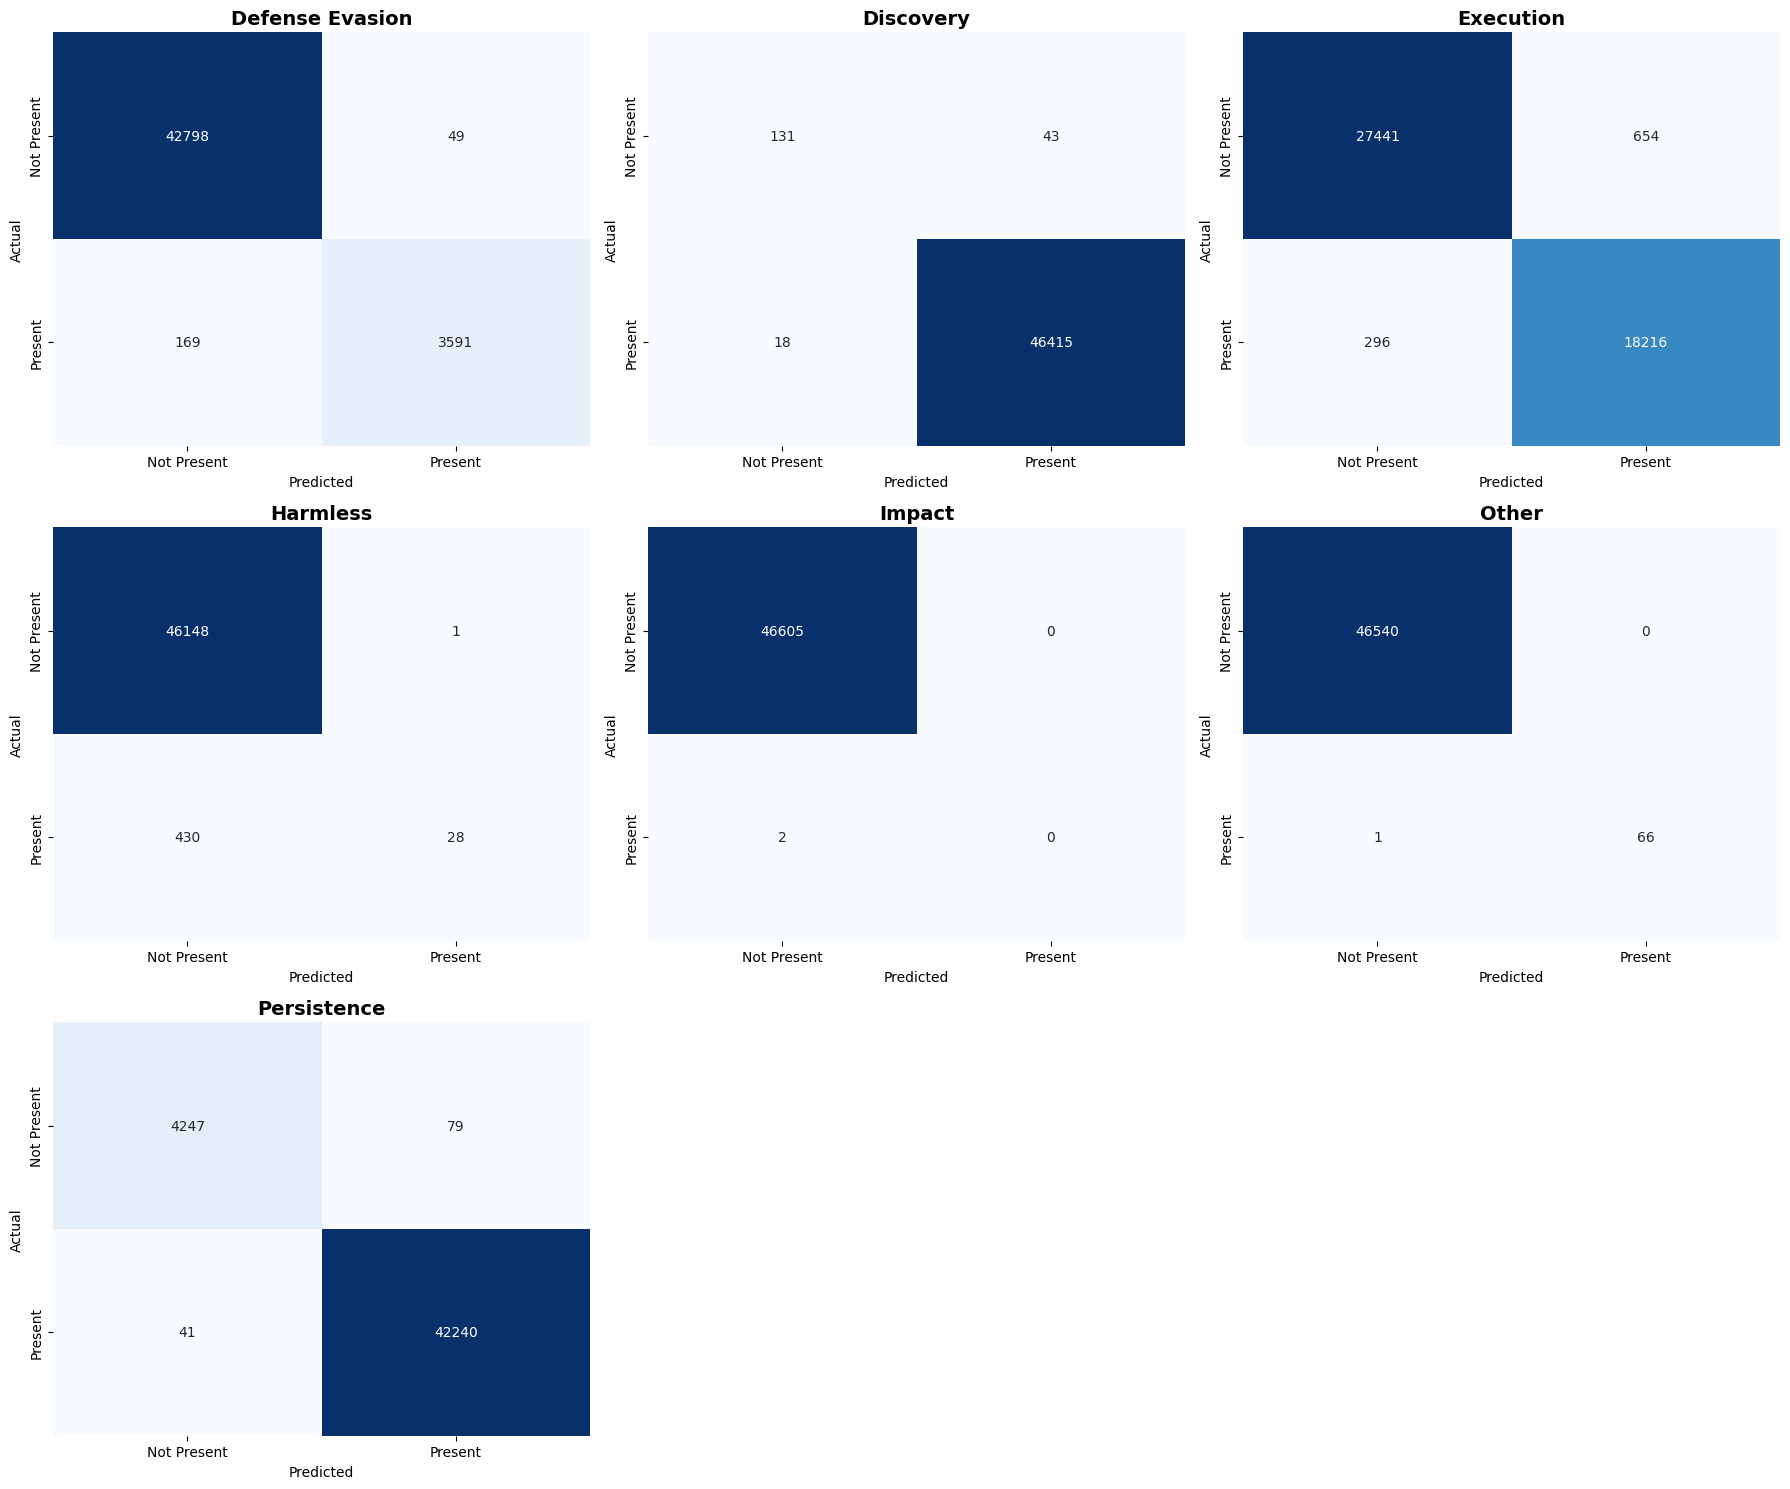

In [22]:
from sklearn.metrics import confusion_matrix

# 1. Get the actual names
# Try to get them from the encoder, otherwise use the hardcoded list
try:
    class_names = mlb.classes_
except NameError:
    # If 'mlb' was lost during restart, this is the standard list for this dataset:
    class_names = ['Discovery', 'Execution', 'Exfiltration', 'Impact', 
                   'Lateral Movement', 'Persistence', 'Privilege Escalation']

print(f"Plotting Confusion Matrices for: {class_names}")

# 2. Setup the plot grid
n_classes = len(class_names)
# Calculate how many rows we need 
rows = (n_classes // 3) + 1
fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, 5 * rows))
axes = axes.flatten()

# Loop through each class
for i, ax in enumerate(axes):
    if i < n_classes:
        # Calculate confusion matrix for this specific class ( eg. Binary: Is it 'Discovery' or Not?)
        cm = confusion_matrix(y_test_true[:, i], (y_test_pred_probs[:, i] >= 0.5).astype(int))
        
        # Plot Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Not Present', 'Present'], 
                    yticklabels=['Not Present', 'Present'])
        
        # Set the Title to the actual Name
        ax.set_title(f"{class_names[i]}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    else:
        # Hide empty subplots 
        ax.axis('off')

plt.tight_layout()
plt.show()

### Learning Curves & ROC Analysis
Retrieves the stored training history and generates two key diagnostic plots:
1.  **Learning Curves:** Visualizes **Training vs. Validation Loss** over epochs to assess model convergence and check for overfitting/underfitting.
2.  **ROC Curves:** Plots the **Receiver Operating Characteristic** for each class, showing the trade-off between True Positive Rate and False Positive Rate. The **AUC (Area Under Curve)** is calculated for each intent to measure overall classification performance.

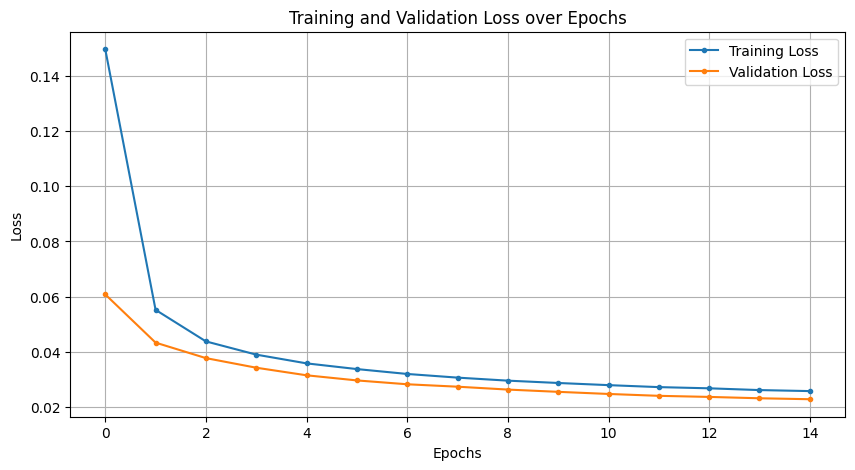

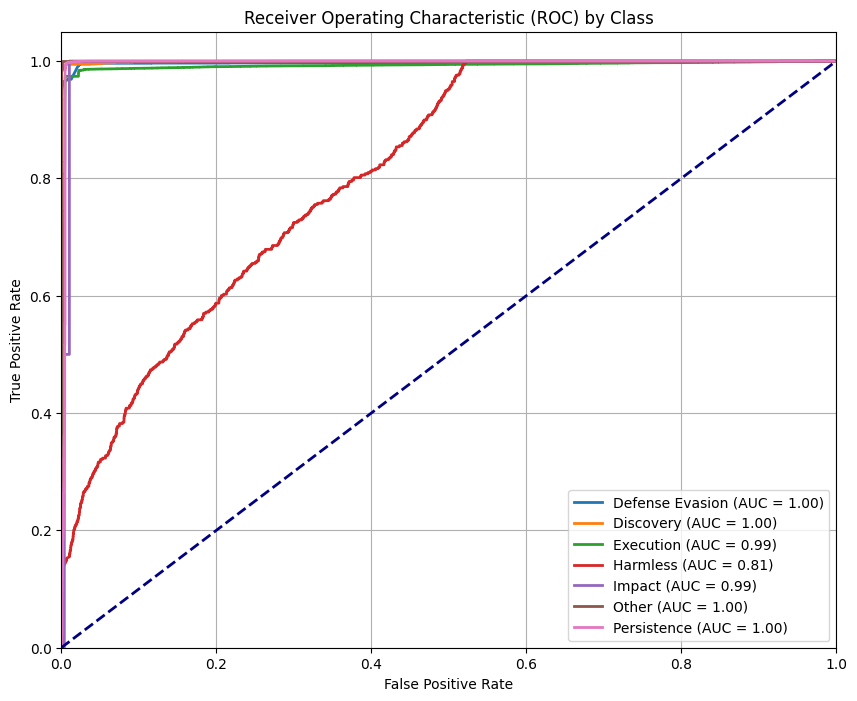

In [23]:
from sklearn.metrics import roc_curve, auc

# 1. Retrieve data
train_losses = model_evaluation['train_losses']
val_losses = model_evaluation['val_losses']
y_true = model_evaluation['true_labels']
y_pred_probs = model_evaluation['predicted_probabilities']
class_names = mlb.classes_


# PLOT 1: Training & Validation Loss (Learning curve)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', marker='.')
plt.plot(val_losses, label='Validation Loss', marker='.')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# PLOT 2: ROC Curves (One line per class)
plt.figure(figsize=(10, 8))

# Loop through each class to plot its specific line
for i, class_name in enumerate(class_names):
    # Calculate False Positive Rate (fpr) and True Positive Rate (tpr)
    # We try/except because if a class is missing in the test set, it crashes
    try:
        fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_name} (AUC = {roc_auc:.2f})')
    except Exception:
        print(f"Skipping ROC for {class_name} (not present in test set)")






plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The 50% random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) by Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Performance Report & Visualization
Generates a detailed performance breakdown. First, it prints the standard text-based **Classification Report** (Precision, Recall, F1-Score). Then, it converts these metrics into a **Grouped Bar Chart** with a custom color palette, allowing for a clear visual comparison of how well the model detects each specific attack intent.

=== Detailed Performance by Class (Text Report) ===

                 precision    recall  f1-score   support

Defense Evasion       0.99      0.96      0.97      3760
      Discovery       1.00      1.00      1.00     46433
      Execution       0.97      0.98      0.97     18512
       Harmless       0.97      0.06      0.11       458
         Impact       0.00      0.00      0.00         2
          Other       1.00      0.99      0.99        67
    Persistence       1.00      1.00      1.00     42281

      micro avg       0.99      0.99      0.99    111513
      macro avg       0.84      0.71      0.72    111513
   weighted avg       0.99      0.99      0.99    111513
    samples avg       0.99      0.99      0.99    111513


=== Visual Performance by Class (Plot) ===


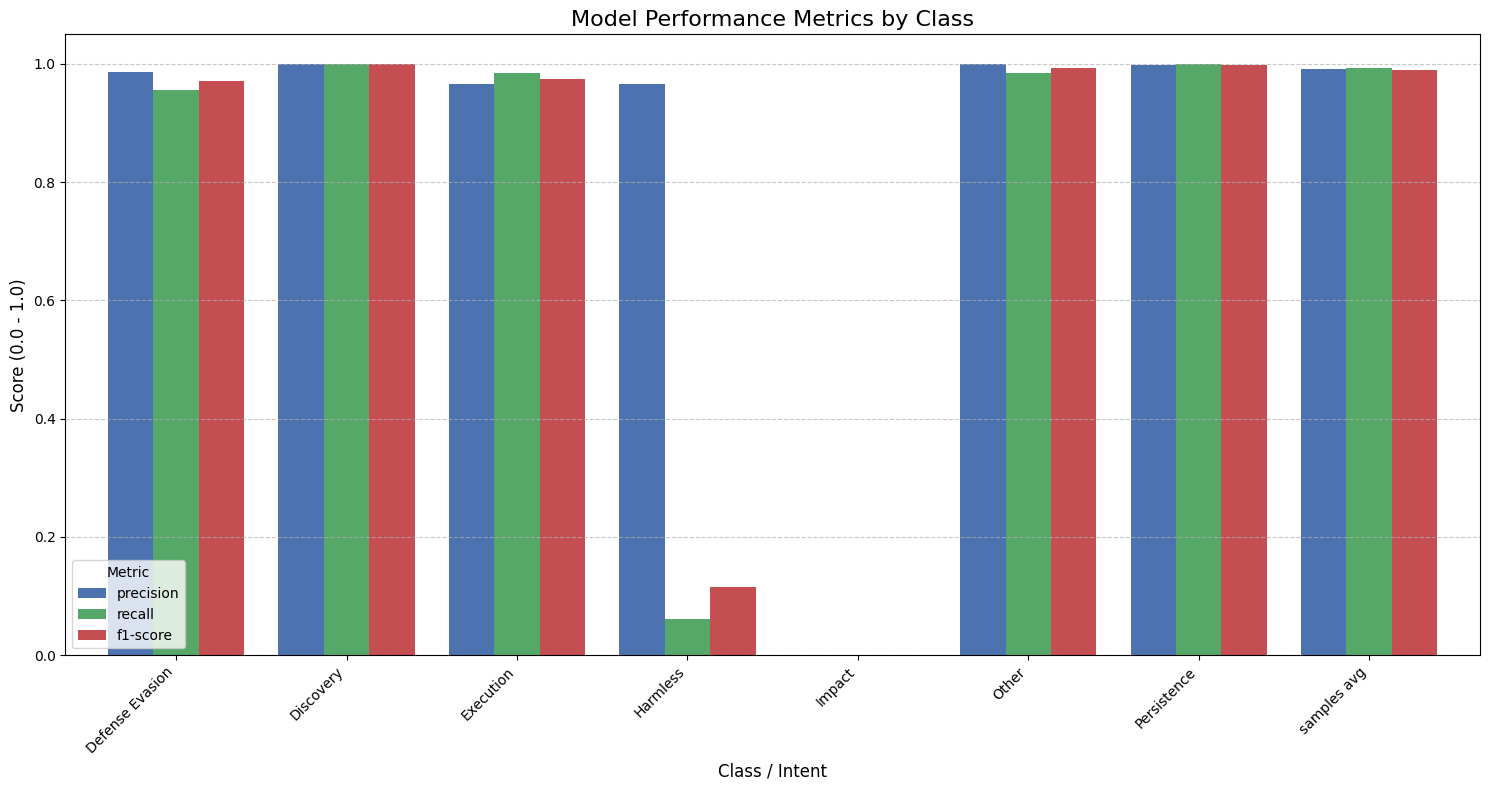

In [24]:
from sklearn.metrics import classification_report

# 1. Get Class Names
# Use the mlb classes if available, otherwise use a fallback
try:
    target_names = mlb.classes_
except NameError:
    target_names = [f"Class {i}" for i in range(y_test_true.shape[1])]

# Convert Probabilities to Binary Predictions (0 or 1)
y_pred_binary = (y_test_pred_probs >= 0.5).astype(int)


# PRINT THE WRITTEN REPORT
print("=== Detailed Performance by Class (Text Report) ===\n")
text_report = classification_report(
    y_test_true, 
    y_pred_binary, 
    target_names=target_names, 
    zero_division=0
)
print(text_report)


# PLOT THE CHART

# Generate the same report but as a Dictionary so we can plot it
report_dict = classification_report(
    y_test_true, 
    y_pred_binary, 
    target_names=target_names, 
    zero_division=0,
    output_dict=True
)

# Convert to DataFrame
df_report = pd.DataFrame(report_dict).transpose()

# Clean data for plotting:
# Remove 'support' column 
# Remove average rows ('micro avg', etc.) 
df_plot = df_report.drop(['support'], axis=1)
df_plot = df_plot.drop(['micro avg', 'macro avg', 'weighted avg', 'samples'], axis=0, errors='ignore')

# Create the Grouped Bar Chart
custom_colors = ['#4c72b0', '#55a868', '#c44e52']

ax = df_plot.plot(kind='bar', figsize=(15, 8), width=0.8, rot=45, color=custom_colors)

# Styling
plt.title("Model Performance Metrics by Class", fontsize=16)
plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("Class / Intent", fontsize=12)
plt.ylim(0.0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower left', title='Metric')

# Rotate x-labels for readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

print("\n=== Visual Performance by Class (Plot) ===")
plt.show()